# An intro to NiSpace

In its essence, NiSpace is a Python package for correlating brain maps with each other. 

Why should we care about this, you ask?

Since many years now, methods that check for overlap between spatial characteristics of different brain maps have been in use. 
More recently, these approaches focused on spatial alignment between group- or individual-level MRI results on one side and brain maps representing potentially underlying biological levels on the other.  
Spatial correlation, or, as we will call them, *spatial colocalization* approaches, play out their key strengths when we have a hypothesis on a biological process underlying a MRI-based finding, but we cannot measure this process directly (or at least, we do not have the data at hand). 

For a straight-forward example, assume you are conducting one of these rather diabolical pain studies. In one condition, you apply electroshocks to your participants (because: why not?) and in the other condition they just lay around. You do that in an MRI scanner and run a functional scan during your task. In a simple task- design, you estimate a T-map telling you which regions activate during pain perception. You might now wonder whether these brain regions (or more specifically: the pattern of activation across regions) are related to neurotransmitter signalling supposedly involved in pain processing. Opioids and noradrenergic/cholinergic pathways come to mind. However, you cannot measure these with MRI and the ethics committee, as well as your wallet, did not allow you to do PET scans. Spatial colocalizations can give you a first hint towards your question: In the simplest case you could check whether the fMRI correlate of pain perception (i.e., your T-map) aligns with expected expression patterns of opioidergic, adrenergic, and cholinergic receptors in the healthy brain. Practically, this can be a simple correlation: If the correlation between all the region-wise values of your T-map and the expression of receptors in the same regions is strongly positive, this might be a good indication that these receptors are involved in pain processing.  
Note the lack of causality! Spatial colocalizations can give you a hint, but not a proof.

In the following, we will use NiSpace to conduct such an analysis.  
First, we will fetch a surrogate for our T-map. Then, we will check if this "T-map" *colocalizes* positively with receptor maps obtained from PET studies in healthy subjects at rest. 

## Imports

In [1]:
# load local nispace, for testing
# COMMENT THIS OUT IF YOU RUN THIS LOCALLY AFTER INSTALLING NISPACE
import sys
sys.path.append("/Users/llotter/projects/nispace/")

# import nispace workflow function
from nispace.workflows import simple_colocalization

# import imaging functions
from nilearn.image import load_img
from nilearn.plotting import view_img

## Get the T-map

I downloaded a meta-analytically derived map automatically generated from the "pain" neuroscientific literature via [NeuroQuery](https://neuroquery.org/query?text=pain+). This is not actually a T-map, but an effect size map. No difference for this example, though.

/Applications/miniforge3/envs/nsp309/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



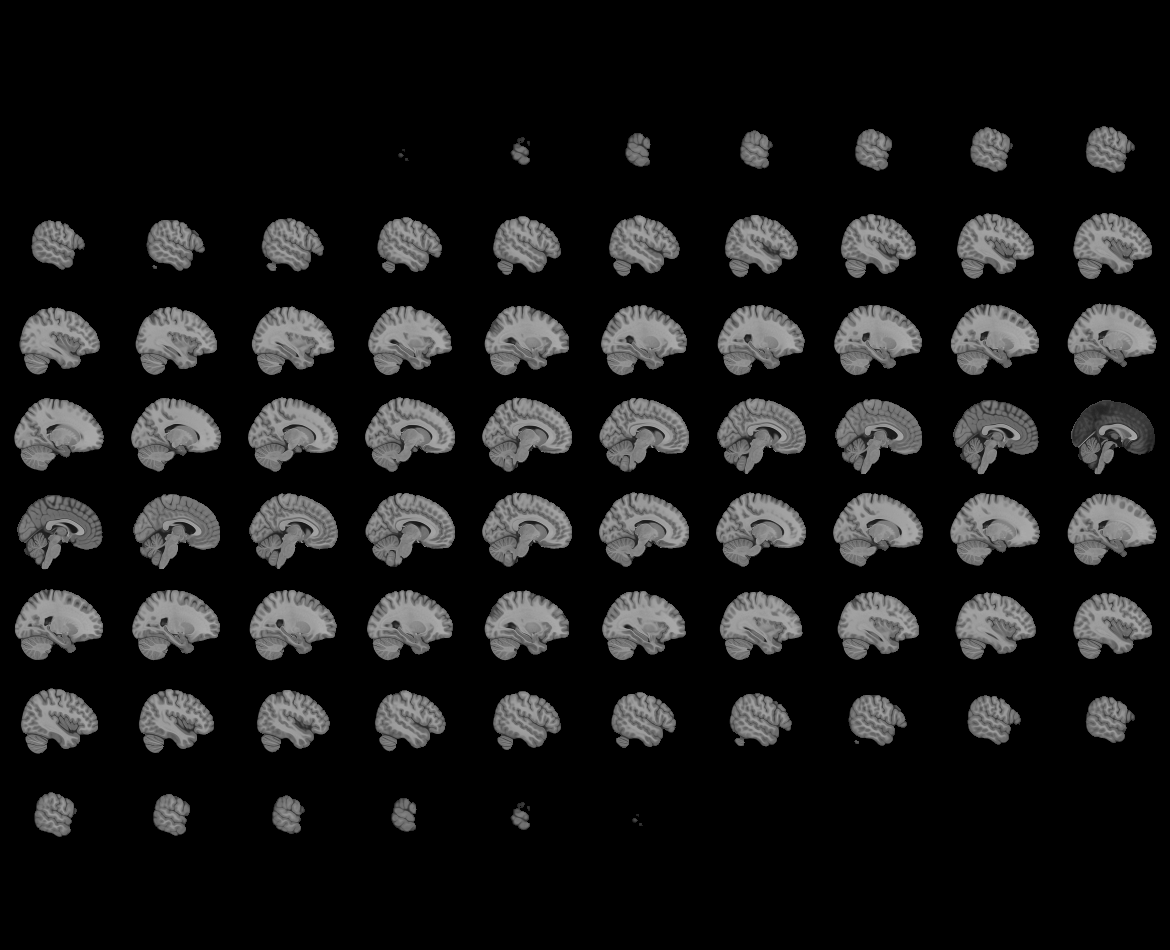
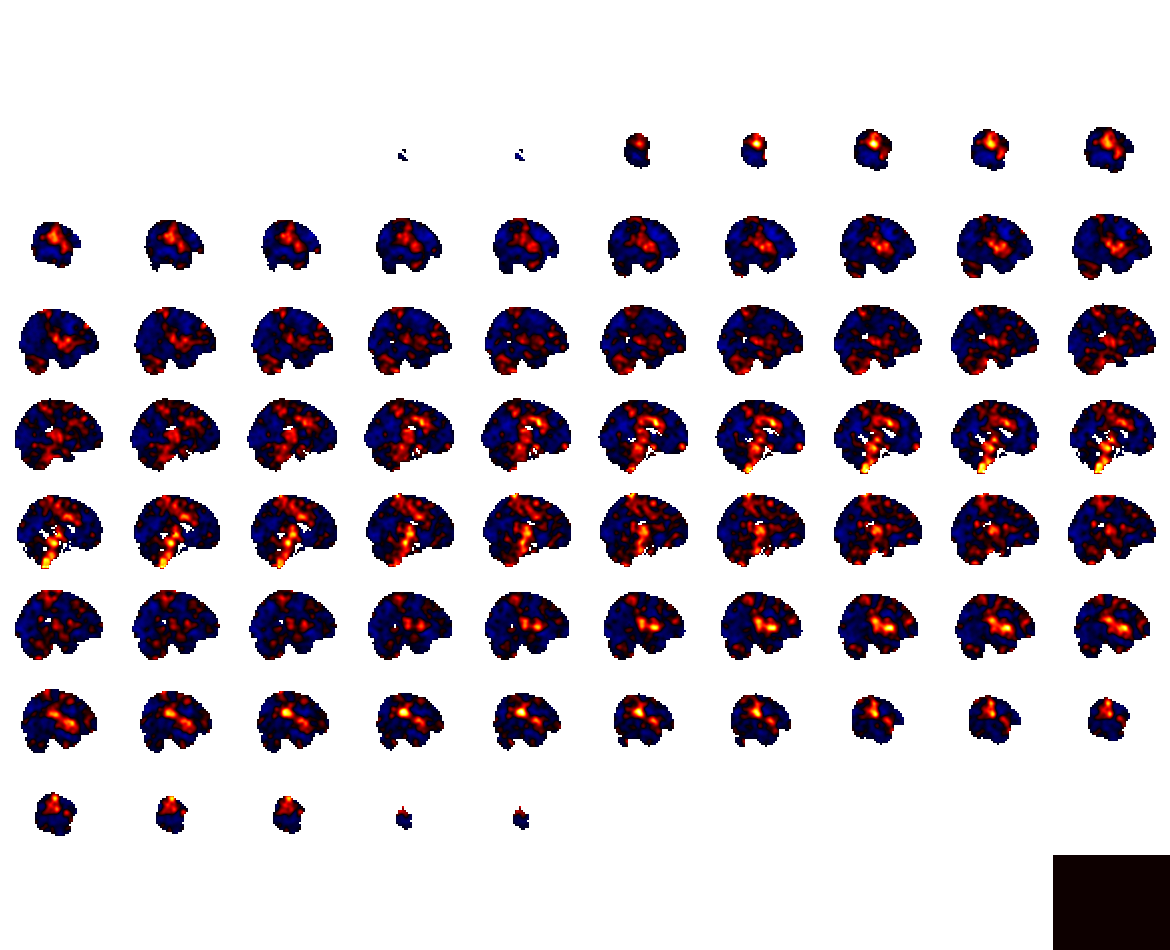

In [2]:
# the download function is a simple function to download a file from a url and save it to a temporary directory
file_path = "neuroquery/pain.nii.gz"

# load the map into memory
effect_map = load_img(file_path)

# plot the map interactively
view_img(effect_map)

## Run the analysis 

We will now run the analysis using a `workflow` function from NiSpace. Workflow functions run a complete analysis, from data loading to plotting, with a single function call.    
We will run the same analysis in individual steps in the next section. 

INFO | 23/07/25 15:26:02 | nispace: Using integrated parcellation Schaefer200.
INFO | 23/07/25 15:26:02 | nispace: Loading integrated pet dataset as X data.
INFO | 23/07/25 15:26:02 | nispace: Using collection UniqueTracers.
INFO | 23/07/25 15:26:02 | nispace: Loading pet maps.
INFO | 23/07/25 15:26:02 | nispace: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 23/07/25 15:26:02 | nispace: Filtering maps by collection.
INFO | 23/07/25 15:26:02 | nispace: Loading data parcellated with 'Schaefer200'
The NiSpace "PET" dataset is based on openly available nuclear imaging maps largely accessed via neuromaps 
(https://neuromaps-main.readthedocs.io/). If requested in the varying original spaces and resolutions (termed "MNI152", 
"fsaverageOriginal", or "fsLROriginal"), the maps are downloaded directly from the source and cached locally. If, as is highly 
recommended, the maps are requested in a defined space ("MNI152NLin2009cAsym", "MNI152NLin6Asym", "fsaverage", or "fs

Parcellating (4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 23/07/25 15:26:06 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 23/07/25 15:26:06 | nispace: Got 'y' data for 1 x 200 parcels.
INFO | 23/07/25 15:26:06 | nispace: Z-standardizing 'X' data.
INFO | 23/07/25 15:26:06 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 23/07/25 15:26:06 | nispace: Running 'spearman' colocalization.
INFO | 23/07/25 15:26:06 | nispace: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 23/07/25 15:26:08 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 23/07/25 15:26:08 | nispace: Permutation of: X maps.
INFO | 23/07/25 15:26:08 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 23/07/25 15:26:08 | nispace: Generating permuted X maps.
INFO | 23/07/25 15:26:08 | nispace: No null maps found.
INFO | 23/07/25 15:26:08 | nispace: Generating null maps (n = 10000, null_method = 'moran').
INFO | 23/07/25 15:26:08 | nispace: Null map generation: Assuming n = 28 data vector(s) for n = 200 parcels.
INFO | 23/07/25 15:26:08 | nispace: Using provided distance matrix/matrices.
INFO | 23/07/25 15:26:08 | nispace: Generating null data separately for left and right hemisphere.


Moran null maps (4 proc):   0%|          | 0/28 [00:00<?, ?it/s]

INFO | 23/07/25 15:26:14 | nispace: Left-to-right mirroring null maps (using left-to-right mapping).
INFO | 23/07/25 15:26:14 | nispace: Matching interhemispheric correlation. Observed correlation: 0.87 (mean), 0.74 - 0.94 (range)


Mirroring null maps:   0%|          | 0/28 [00:00<?, ?it/s]

INFO | 23/07/25 15:26:18 | nispace: Null data generation finished.
INFO | 23/07/25 15:26:18 | nispace: Z-standardizing null maps.
INFO | 23/07/25 15:26:19 | nispace: Pre-ranking X and Y (null) data.


Processing null arrays (4 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

Null colocalizations (spearman, 4 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 23/07/25 15:26:21 | nispace: Calculating exact p-values (tails = {'rho': 'upper'}).
INFO | 23/07/25 15:26:21 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 23/07/25 15:26:21 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 23/07/25 15:26:22 | nispace: Creating categorical plot for method spearman, colocalization stat rho.


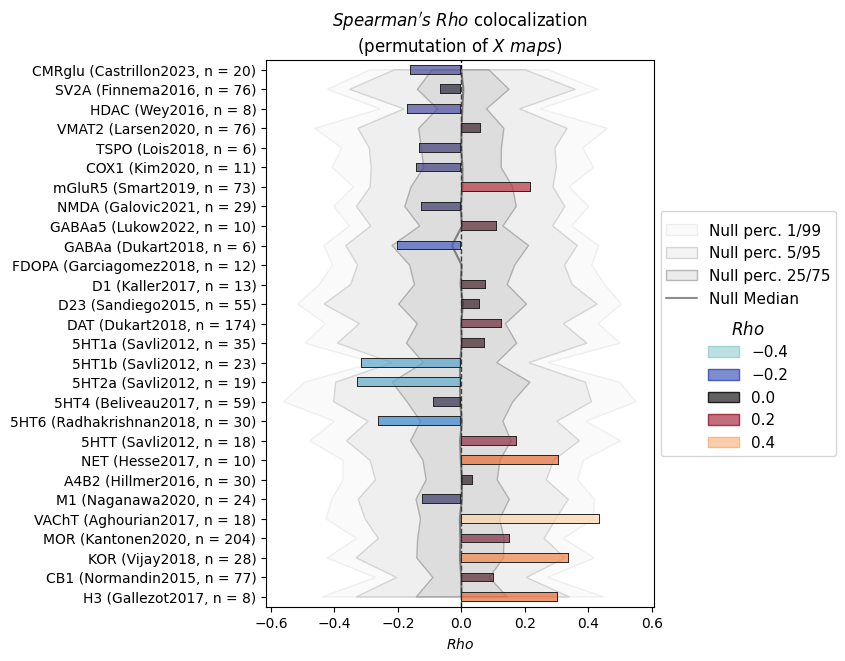

INFO | 23/07/25 15:26:23 | nispace: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
INFO | 23/07/25 15:26:23 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False | False       | False       | 
INFO | 23/07/25 15:26:23 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | fdrbh     | False | False       | False       | 


In [3]:
colocalization, p_values, p_fdr_values, nispace_object = simple_colocalization(
    y={"Pain": effect_map}, # our effect map, with the dictionary we can pass a name, can also be just the effect map
    x="pet", # the PET data, here, a pre-parcellated set of PET maps is automatically downloaded
    permute_kwargs={"p_tails": "upper"}, # This tells the function to calculate right-tailed p values according to our hypothesis
    parcellation="Schaefer200", # the parcellation to use, here, Schaefer200
    seed=42, # the seed to use for the permutation analysis, for reproducibility
    n_proc=4 # number if parallel processes to use when possible
)

Look at that. The colorful plot in the end shows us the spatial colocalization values on the x axis (here: Z-transformed Spearman's rho). The y axis shows each PET map that went into the analysis.  
The gray shades indicate the distribution of colocalization values when the PET maps were random but contained the same level of spatial autocorrelation (i.e., a similar core spatial structure).  

As hypothesized, we observe positive colocalizations for the acetylcholine transpoter (VAChT), the noradrenergic transporter (NET), and the K-opioid receptor (KOR).  
As one can infer from the plot, the colocalizations look relatively strong, but the p values are not very low. This we see often when using group-average effect maps. An analysis of the individual maps might give us stronger effects.

The workflow function returns dataframes with colocalization values, p values, and FDR-corrected p values. Let's take a look at the p values.

In [4]:
# the p value dataframe contains one row for each input (y) map and one column for each reference (x) map
print("Output p values:")
display(p_values)

# we can display this a bit more nicely by transposing and sorting in ascending order
print("Sorted p values:")
p_values.T.sort_values(by="Pain")

Output p values:


set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
Pain                                             0.8918       

set                                                      \
map  target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
Pain                                             0.6442   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
Pain                                              0.939     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
Pain                                             0.3798   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
Pain                                          0.7628   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
Pain                                           0.79   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
Pain                                             0.1538     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
Pain                                             0.6632    

set                                                    GABA  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022   
Pain                                              0.292       

set                                                           ...  \
map  target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018  ...   
Pain                                             0.7291       ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
Pain                                             0.9287              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
Pain                                           0.2241   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
Pain                                         0.0375   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
Pain                                             0.4197        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
Pain                                             0.7191        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
Pain                                             0.0065       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
Pain                                              0.214           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
Pain                                             0.0419     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
Pain                                             0.2183    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
Pain                                             0.0732     

[1 rows x 28 columns]

Sorted p values:


Pain
set                         map                                                       
Noradrenaline/Acetylcholine target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghour...  0.0065
                            target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017      0.0375
Opiods/Endocannabinoids     target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vija...  0.0419
Histamine                   target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallez...  0.0732
Glutamate                   target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smar...  0.1538
Opiods/Endocannabinoids     target-MOR_tracer-carfentanil_n-204_dx-hc_pub-k...  0.2140
                            target-CB1_tracer-omar_n-77_dx-hc_pub-normandin...  0.2183
Serotonin                   target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.2241
Dopamine                    target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.2676
GABA                        target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...  0.2920
Dopamine                    target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller...  0.3544
General                     target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020  0.3798
Serotonin                   target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...  0.3918
Noradrenaline/Acetylcholine target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hil...  0.4197
Dopamine                    target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg...  0.4203
                            target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...  0.5025
Serotonin                   target-5HT4_tracer-sb207145_n-59_dx-hc_pub-beli...  0.6241
General                     target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016  0.6442
Glutamate                   target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic...  0.6632
Noradrenaline/Acetylcholine target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naga...  0.7191
GABA                        target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-du...  0.7291
Immunity                    target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018     0.7628
                            target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020      0.7900
General                     target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...  0.8918
Serotonin                   target-5HT2a_tracer-altanserin_n-19_dx-hc_pub-s...  0.8927
                            target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-rad...  0.9287
General                     target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...  0.9390
Serotonin                   target-5HT1b_tracer-p943_n-23_dx-hc_pub-savli2012   0.9980

VAChT shows the strongest effect, NET and KOR p values are around 0.05. As I wrote above, effects are often stronger when using individual maps.  
Nevertheless, there is an overall pattern that suggests that the pain-related activation distributes across the brain according to expected neurotransmitter pathways.

## Run the analysis in individual steps

We will now run the same analysis in individual steps. This will give us more flexibility and transparency and might help to understand what's happening. 

### Load the data

We have loaded the effect map already. Now, we load the PET maps via nispace's `fetch_reference` function.
Without additional arguments, this will download and return all PET maps contained in NiSpace's reference collection, nonlinearly aligned to defined MNI152 spaces. A long list of references will be printed automatically, like you can see in the output above. 

Here, we load a predefined set of data (`collection="UniqueTracers"`) in a specific parcellation (`parcellation="Schaefer200"`), which will return a dataframe of shape (n_maps, n_parcels). We suppress the reference list by setting `print_references=False`.

In [5]:
from nispace.datasets import fetch_reference

# fetch the PET maps
pet_maps = fetch_reference("pet", parcellation="Schaefer200", collection="UniqueTracers",
                           print_references=False)

# show the dataframe
print("PET maps dataframe. Shape:", pet_maps.shape)
pet_maps.head()

INFO | 23/07/25 15:26:23 | nispace: Loading pet maps.
INFO | 23/07/25 15:26:23 | nispace: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 23/07/25 15:26:23 | nispace: Filtering maps by collection.
INFO | 23/07/25 15:26:23 | nispace: Loading data parcellated with 'Schaefer200'
PET maps dataframe. Shape: (28, 200)


hemi-L_div-Vis_lab-1  \
set      map                                                                        
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.677147   
         target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.651551   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...              0.669746   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020              0.037109   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018                 0.639551   

                                                             hemi-L_div-Vis_lab-2  \
set      map                                                                        
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.666611   
         target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.606582   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...              0.698529   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020              0.024958   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018                 0.656742   

                                                             hemi-L_div-Vis_lab-3  \
set      map                                                                        
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.633823   
         target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.616104   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...              0.655808   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020              0.020044   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018                 0.672583   

                                                             hemi-L_div-Vis_lab-4  \
set      map                                                                        
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.712379   
         target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.570561   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...              0.702535   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020              0.022149   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018                 0.688357   

                                                             hemi-L_div-Vis_lab-5  \
set      map                                                                        
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.604150   
         target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.536395   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...              0.630375   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020              0.012398   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018                 0.611939   

                                                             hemi-L_div-Vis_lab-6  \
set      map                                                                        
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.590683   
         target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.509607   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...              0.546337   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020              0.019778   
Immunity target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018                 0.617067   

                                                             hemi-L_div-Vis_lab-7  \
set      map                                                                        
General  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...              0.707724   
         target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016              0.563901   
         target-HDAC_tracer-martinostat_n-8_dx-hc_pub-we...              0.722179   
         target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020 

### Initialize the NiSpace instance and run the data extraction

NiSpace is coded in an object-oriented way. We first initialize a NiSpace object and then run methods on it.  
Here, we initialize a NiSpace object with the effect map as dependent variable and the PET maps as independent variables.

In [6]:
from nispace.api import NiSpace

# pass the data to the NiSpace object
nsp = NiSpace(
    x=pet_maps,
    y=effect_map,
    y_labels="Pain",
    data_space="MNI152NLin6Asym",
    parcellation="Schaefer200",
    return_self=True, # for compatibility with future versions
)

# run the data extraction
nsp.fit()

INFO | 23/07/25 15:26:23 | nispace: *** NiSpace.fit() - Data extraction and preparation. ***
INFO | 23/07/25 15:26:23 | nispace: Loading cortex parcellation 'Schaefer200' in 'MNI152NLin2009cAsym' space.
INFO | 23/07/25 15:26:23 | nispace: Loaded integrated parcellation with pre-calculated distance matrix.
INFO | 23/07/25 15:26:23 | nispace: Checking input data for 'x' (should be, e.g., PET data):
INFO | 23/07/25 15:26:23 | nispace: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).
WARNING | 23/07/25 15:26:23 | nispace: Parcellated data contains nan values!
INFO | 23/07/25 15:26:23 | nispace: Got 'x' data for 28 x 200 parcels.
INFO | 23/07/25 15:26:23 | nispace: Checking input data for 'y' (should be, e.g., subject data):
INFO | 23/07/25 15:26:23 | nispace: Input type: list, assuming imaging data.
INFO | 23/07/25 15:26:24 | nispace: Parcellating imaging data.


Parcellating (1 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 23/07/25 15:26:24 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 23/07/25 15:26:24 | nispace: Got 'y' data for 1 x 200 parcels.
INFO | 23/07/25 15:26:24 | nispace: Z-standardizing 'X' data.


With this, we performed parcellation of the input data (the effect map). The PET maps were already passed as a dataframe with regional values.

We can take a look at the parcellated input data. Again, one row per input map, one column per parcel.

In [7]:
nsp.get_y()

INFO | 23/07/25 15:26:24 | nispace: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


,hemi-L_div-Vis_lab-1,hemi-L_div-Vis_lab-2,hemi-L_div-Vis_lab-3,hemi-L_div-Vis_lab-4,hemi-L_div-Vis_lab-5,hemi-L_div-Vis_lab-6,hemi-L_div-Vis_lab-7,hemi-L_div-Vis_lab-8,hemi-L_div-Vis_lab-9,hemi-L_div-Vis_lab-10,...,hemi-R_div-Default_lab-PFCm+1,hemi-R_div-Default_lab-PFCm+2,hemi-R_div-Default_lab-PFCm+3,hemi-R_div-Default_lab-PFCm+4,hemi-R_div-Default_lab-PFCm+5,hemi-R_div-Default_lab-PFCm+6,hemi-R_div-Default_lab-PFCm+7,hemi-R_div-Default_lab-PCC+1,hemi-R_div-Default_lab-PCC+2,hemi-R_div-Default_lab-PCC+3
Pain,-0.436623,-1.075635,-0.893094,-0.887707,-1.139506,-1.259002,-1.339256,-1.083586,-1.389717,-0.828569,...,-0.463824,-0.154211,0.643321,-0.584073,-0.205924,0.174392,0.172215,-0.319737,-0.818837,-0.344202


## Run the colocalization analysis

We can now run the colocalization analysis. We will use the `colocalize` method of the NiSpace object. We use simple Spearman correlations.

In [8]:
nsp.colocalize("spearman")
colocalization_manual = nsp.get_colocalizations()

INFO | 23/07/25 15:26:24 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 23/07/25 15:26:24 | nispace: Running 'spearman' colocalization.
INFO | 23/07/25 15:26:24 | nispace: Pre-ranking X and Y data.


Colocalizing (spearman, 1 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 23/07/25 15:26:24 | nispace: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


We can again take a look at the results that were returned by the `colocalize` method.  
The same will be returned by `nsp.get_colocalizations()`.

In [9]:
display(colocalization_manual)

# this should be the same as the output from the workflow function
assert (colocalization_manual.values == colocalization.values).all(), "Values are not the same"

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
Pain                                          -0.162803       

set                                                      \
map  target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
Pain                                          -0.068091   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
Pain                                          -0.170727     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
Pain                                           0.062397   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
Pain                                       -0.134217   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
Pain                                      -0.142131   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
Pain                                           0.219451     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
Pain                                          -0.127164    

set                                                    GABA  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022   
Pain                                           0.111743       

set                                                           ...  \
map  target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018  ...   
Pain                                          -0.202272       ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
Pain                                          -0.264142              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
Pain                                         0.176491   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
Pain                                       0.309315   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
Pain                                           0.036321        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
Pain                                          -0.122528        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
Pain                                           0.435971       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
Pain                                           0.151909           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
Pain                                           0.339014     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
Pain                                           0.102278    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
Pain                                           0.304823     

[1 rows x 28 columns]

### Estimate p values via permutation analysis

We will now estimate the p values by permuting the independent variables (x, PET maps) and re-running the colocalization analysis.  
This is achieved by the `permute` method of the NiSpace object.  

In [10]:
nsp.permute("maps", p_tails="upper", seed=42)
p_values_manual = nsp.get_p_values()

INFO | 23/07/25 15:26:24 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 23/07/25 15:26:24 | nispace: Permutation of: X maps.
INFO | 23/07/25 15:26:24 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 23/07/25 15:26:24 | nispace: Generating permuted X maps.
INFO | 23/07/25 15:26:24 | nispace: No null maps found.
INFO | 23/07/25 15:26:24 | nispace: Generating null maps (n = 10000, null_method = 'moran').
INFO | 23/07/25 15:26:24 | nispace: Null map generation: Assuming n = 28 data vector(s) for n = 200 parcels.
INFO | 23/07/25 15:26:24 | nispace: Using provided distance matrix/matrices.
INFO | 23/07/25 15:26:24 | nispace: Generating null data separately for left and right hemisphere.


Moran null maps (1 proc):   0%|          | 0/28 [00:00<?, ?it/s]

INFO | 23/07/25 15:26:39 | nispace: Left-to-right mirroring null maps (using left-to-right mapping).
INFO | 23/07/25 15:26:39 | nispace: Matching interhemispheric correlation. Observed correlation: 0.87 (mean), 0.74 - 0.94 (range)


Mirroring null maps:   0%|          | 0/28 [00:00<?, ?it/s]

INFO | 23/07/25 15:26:43 | nispace: Null data generation finished.
INFO | 23/07/25 15:26:43 | nispace: Z-standardizing null maps.
INFO | 23/07/25 15:26:44 | nispace: Pre-ranking X and Y (null) data.


Processing null arrays (1 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

Null colocalizations (spearman, 1 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 23/07/25 15:26:48 | nispace: Calculating exact p-values (tails = {'rho': 'upper'}).
INFO | 23/07/25 15:26:48 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False | False       | False       | 


Again, we look at the results. You should have gotten the hang of it by now, right?

In [11]:
display(p_values_manual)

# this should be the same as the output from the workflow function
assert (p_values_manual.values == p_values.values).all(), "Values are not the same"

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
Pain                                             0.8918       

set                                                      \
map  target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
Pain                                             0.6442   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
Pain                                              0.939     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
Pain                                             0.3798   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
Pain                                          0.7628   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
Pain                                           0.79   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
Pain                                             0.1538     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
Pain                                             0.6632    

set                                                    GABA  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022   
Pain                                              0.292       

set                                                           ...  \
map  target-GABAa_tracer-flumazenil_n-6_dx-hc_pub-dukart2018  ...   
Pain                                             0.7291       ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
Pain                                             0.9287              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
Pain                                           0.2241   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
Pain                                         0.0375   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
Pain                                             0.4197        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
Pain                                             0.7191        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
Pain                                             0.0065       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
Pain                                              0.214           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
Pain                                             0.0419     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
Pain                                             0.2183    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
Pain                                             0.0732     

[1 rows x 28 columns]

### Plot the results

There's a plot method for the NiSpace object. It tries to find the best way to visualize the results. I admit, this it not always successful in the current state, but it's a good starting point.

INFO | 23/07/25 15:26:48 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 23/07/25 15:26:49 | nispace: Creating categorical plot for method spearman, colocalization stat rho.


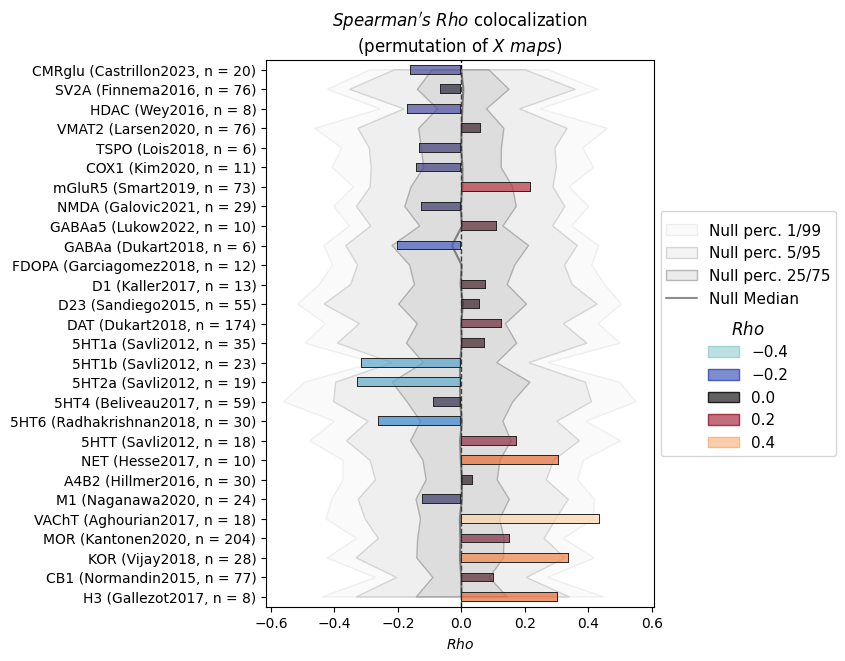

(<Figure size 500x710 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x179b4c7f0>)

In [12]:
nsp.plot()

### Save the NiSpace object

We can save NiSpace objects using the integrated `to_pickle()` method. It makes sense to use compression.  
Allowed file extensions are:
- `.pkl`
- `.pkl.gz`
- `.pkl.blosc`

We recommend using `.pkl.blosc` for the best performance.

When null runs have been performed, nispace objects can be quite large. There is an option to drop the nulls before saving, but that might not be what you want.  
For example, the plot above would have to be created without the null distribution if the nulls are dropped.

In [13]:
import os

# save the complete nispace object
nsp.to_pickle("nispace_object.pkl.blosc")
# file size
print(f"File size: {os.path.getsize('nispace_object.pkl.blosc') / 1024**2:.2f} MB")

# save the nispace object without nulls
nsp.to_pickle("nispace_object_no_nulls.pkl.blosc", save_nulls=False)
# file size
print(f"File size when nulls are dropped: {os.path.getsize('nispace_object_no_nulls.pkl.blosc') / 1024**2:.2f} MB")

File size: 408.09 MB
File size when nulls are dropped: 4.16 MB


For demonstration purposes, we will now load the nispace object without nulls and try to create the plot above.

Reloaded nispace object: <nispace.api.NiSpace object at 0x179bd2b20>
INFO | 23/07/25 15:26:51 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
WARNING | 23/07/25 15:26:51 | nispace: No nulls found. Not plotting null distributions.
INFO | 23/07/25 15:26:51 | nispace: Creating categorical plot for method spearman, colocalization stat rho.


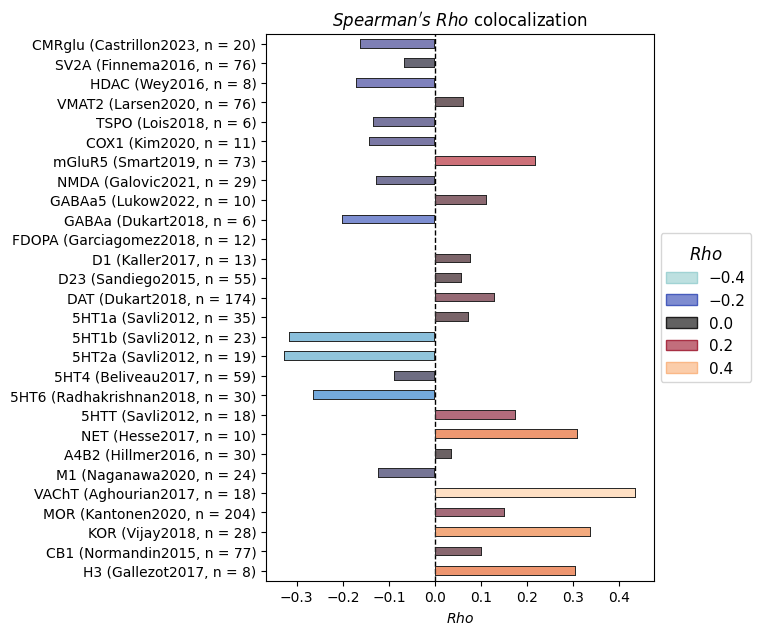

(<Figure size 500x710 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x179aa29d0>)

In [14]:
# load the nispace object without nulls
nsp_loaded_no_nulls = NiSpace.from_pickle("nispace_object_no_nulls.pkl.blosc")
print("Reloaded nispace object:", nsp_loaded_no_nulls)

# we will get a warning if we try to plot the nispace object and the plot will not have the nulls
nsp_loaded_no_nulls.plot(plot_nulls=True)

## Extra: Nice correlation plot of the main result

We will create a plot of the input data projected on a brain together with the correlation between the input map and the VAChT map, which showed the strongest colocalization.

First, load the parcellated data.

In [15]:
# get the parcellated effect map
effect_map_parcellated = nsp.get_y().loc["Pain"]
display(effect_map_parcellated.head())

# get the parcellated "VAChT" PET map
k = ("Noradrenaline/Acetylcholine", "target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017")
VAChT_parcellated = nsp.get_x().loc[k]
# rename to "VAChT"
VAChT_parcellated.name = "VAChT"
display(VAChT_parcellated.head())

# plot 

INFO | 23/07/25 15:26:51 | nispace: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


hemi-L_div-Vis_lab-1   -0.436623
hemi-L_div-Vis_lab-2   -1.075635
hemi-L_div-Vis_lab-3   -0.893094
hemi-L_div-Vis_lab-4   -0.887707
hemi-L_div-Vis_lab-5   -1.139506
Name: Pain, dtype: float32

INFO | 23/07/25 15:26:51 | nispace: Returning X dataframe: 
| X_REDUCTION | 
| False       | 


hemi-L_div-Vis_lab-1   -0.508933
hemi-L_div-Vis_lab-2   -0.861415
hemi-L_div-Vis_lab-3   -0.726180
hemi-L_div-Vis_lab-4   -1.245316
hemi-L_div-Vis_lab-5   -1.428280
Name: VAChT, dtype: float32

Now, create the plot. Understand the code requires some knowledge of plotting in Python.

Text(0.05, 0.95, 'r = 0.44, p = 0.007')

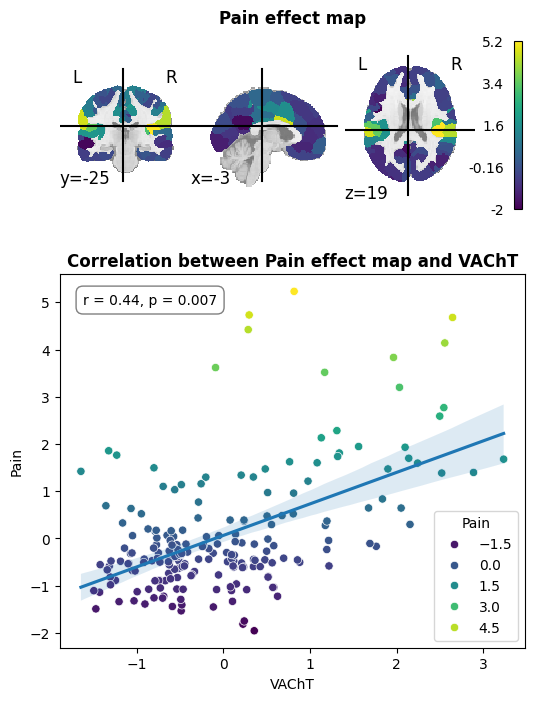

In [19]:
from seaborn import regplot,scatterplot
from matplotlib import pyplot as plt
from nilearn.plotting import plot_stat_map
from nispace.utils.utils import parc_vect_to_vol

# initialize figure
fig, (ax_brain, ax_scatter) = plt.subplots(2, 1, figsize=(6, 8), gridspec_kw={"height_ratios": [1, 2]})

# plot brains, the function parc_vect_to_vol converts the parcellated vector to a 3D image given a parcellation image
ax_brain.set_title("Pain effect map", fontweight="bold")
effect_map_parcellated_img = parc_vect_to_vol(effect_map_parcellated, nsp._parc._image_obj)
plot_stat_map(
    effect_map_parcellated_img,
    cmap="viridis", symmetric_cbar=False, 
    axes=ax_brain
)

# plot scatter plot and regression line
ax_scatter.set_title("Correlation between Pain effect map and VAChT", fontweight="bold")
scatterplot(
    y=effect_map_parcellated, x=VAChT_parcellated, 
    hue=effect_map_parcellated, palette="viridis", sizes=15,
    ax=ax_scatter
)
regplot(
    y=effect_map_parcellated, x=VAChT_parcellated, 
    scatter=False, 
    ax=ax_scatter
)

# plot stats results
r = colocalization_manual.loc['Pain', k]
p = p_values_manual.loc['Pain', k]
ax_scatter.annotate(
    xy=(0.05, 0.95), xycoords="axes fraction",
    text=f"r = {r:0.2f}, p = {p:0.3f}",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.5, boxstyle="round,pad=0.5"),
)